# NYC Police Patrol Scheduling in Brooklyn
The purpose of this notebook is to use use the crime incident prediction data from the machine learning results to determine an optimal patrol schedule for Brooklyn.

In [56]:
#Imports and data loading
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from datetime import datetime
import matplotlib.pyplot as plt

#Load the predictions generated in the ML notebook
df = pd.read_csv('crime_predictions.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset Loaded. Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Dataset Loaded. Date range: 2018-08-09 to 2019-01-01


##### Date Shifting for Streamlit Dashboard Interactivity
Since the current dataset ends in 2019, this block "time travels" the data to the current week so that the Streamlit calendar picker works for "now"

In [57]:
#Calculate the offset to bring the 2019 data to today's date
max_data_date = df['date'].max()
today = datetime.now().replace(hour=0, minute=0, second=0, microsecond=0)
offset = today - max_data_date

#Shift all dates
df['date'] = df['date'] + offset

#Save this version specifically for the Streamlit dashboard
df.to_csv('crime_predictions_streamlit.csv', index=False)

print(f"Dates shifted by {offset.days} days.")
print(f"New 'Today' in the data is: {df['date'].max().date()}")

Dates shifted by 2654 days.
New 'Today' in the data is: 2026-04-08


## Optimization Model
Assigns officers to different precinct jurisdictions depending on predicted crime rate for that day given resource constraints

In [58]:
def run_patrol_optimization(input_df, target_date, total_daily_budget, efficiency=0.05):
    """
    input_df: The crime predictions dataframe
    target_date: The date to optimize for (string 'YYYY-MM-DD')
    total_daily_budget: Total officer-shifts available for the WHOLE 24-hour day
    efficiency: The coverage capacity per officer unit
    """
    day_data = input_df[input_df['date'] == target_date].copy()
    if day_data.empty: return None

    #Parameters
    MAX_STAFF_PER_PRECINCT = 60
    
    m = gp.Model("Strategic_Patrol_Deployment")
    m.setParam('OutputFlag', 0)

    #Sets
    precincts = day_data['ADDR_PCT_CD'].unique()
    shifts = day_data['shift_window'].unique()

    #Decision Variables
    x = m.addVars(precincts, shifts, vtype=GRB.INTEGER, lb=0, ub=MAX_STAFF_PER_PRECINCT, name="units")
    risk = m.addVars(precincts, shifts, lb=0, name="uncovered_risk")

    #Constraints
    
    #Global Daily Workforce Limit
    m.addConstr(gp.quicksum(x[p, s] for p in precincts for s in shifts) <= total_daily_budget, 
                name="daily_workforce_capacity")

    #Risk Definition: Residual Risk >= Predicted - (Assigned * Efficiency)
    for _, row in day_data.iterrows():
        p, s, pred = row['ADDR_PCT_CD'], row['shift_window'], row['predicted_incidents']
        m.addConstr(risk[p, s] >= pred - (x[p, s] * efficiency))

    #Objective Function
    #Minimize weighted risk
    obj = gp.quicksum(
        risk[p, s] * (2.0 if day_data[(day_data['ADDR_PCT_CD']==p) & (day_data['shift_window']==s)]['high_risk'].iloc[0] == 1 else 1.0)
        for p in precincts for s in shifts
    )
    
    #Run optimization
    m.setObjective(obj, GRB.MINIMIZE)
    m.optimize()

    #Extract Results
    if m.status == GRB.OPTIMAL:
        results = []
        for p in precincts:
            for s in shifts:
                results.append({
                    'Precinct': p,
                    'Shift': day_data[day_data['shift_window']==s]['shift_label'].iloc[0],
                    'Required_Officers': int(x[p, s].X)
                })
        return pd.DataFrame(results)
    return None

In [59]:
#Test run for 'Today'
demo_date = df['date'].max().strftime('%Y-%m-%d')
deployment_plan = run_patrol_optimization(df, demo_date, total_daily_budget=120)

if isinstance(deployment_plan, pd.DataFrame):
    #Display top 10 recommended placements
    print(f"Optimal Deployment for {demo_date}:")
    display(deployment_plan.sort_values(by='Required_Officers', ascending=False).head(10))
else:
    print(deployment_plan)

Optimal Deployment for 2026-04-08:


,Precinct,Shift,Required_Officers
40,63,16:00–20:00,12
50,67,08:00–12:00,11
51,67,12:00–16:00,11
92,75,08:00–12:00,10
94,75,16:00–20:00,9
38,63,08:00–12:00,9
93,75,12:00–16:00,9
46,66,16:00–20:00,7
47,66,20:00–24:00,7
87,73,12:00–16:00,7


## Sensitivity Analysis
Determine how the model results change as parameters/constraints are changed

#### Impact of Police Budget
This code iterates through different budget levels to show how much "Safety" is bought with each additional officer

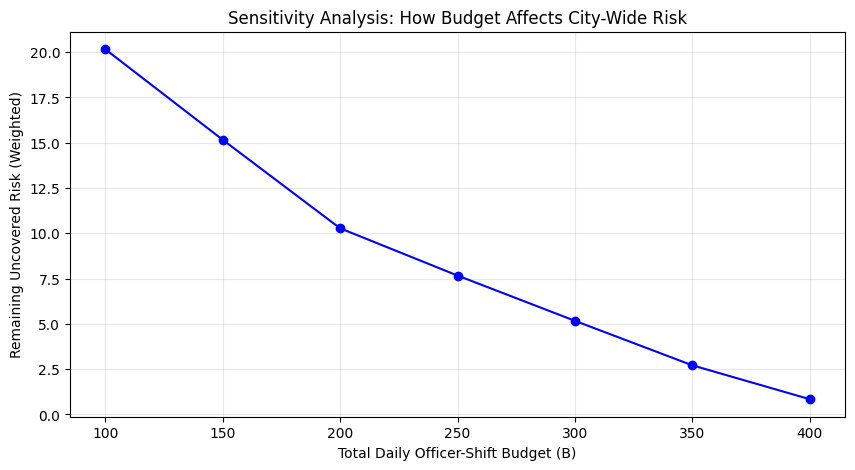

In [60]:
#Range of daily budgets to test
test_budgets = [100, 150, 200, 250, 300, 350, 400]
sensitivity_results = []

demo_date = df['date'].max().strftime('%Y-%m-%d')

for b in test_budgets:
    #Run optimization for this budget
    plan = run_patrol_optimization(df, demo_date, total_daily_budget=b)
    
    if plan is not None:
        #Calculate the Total Weighted Risk for this plan
        total_risk = 0
        for _, row in plan.iterrows():
            orig = df[(df['date'] == demo_date) & 
                      (df['ADDR_PCT_CD'] == row['Precinct']) & 
                      (df['shift_label'] == row['Shift'])].iloc[0]
            row_risk = max(0, orig['predicted_incidents'] - (row['Required_Officers'] * 0.05))
            weighted_row_risk = row_risk * (2.0 if orig['high_risk'] == 1 else 1.0)
            total_risk += weighted_row_risk
            
        sensitivity_results.append({'Budget': b, 'Total_Residual_Risk': total_risk})

sens_df = pd.DataFrame(sensitivity_results)

#Plot the Elbow Curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(sens_df['Budget'], sens_df['Total_Residual_Risk'], marker='o', linestyle='-', color='b')
plt.title("Sensitivity Analysis: How Budget Affects City-Wide Risk")
plt.xlabel("Total Daily Officer-Shift Budget (B)")
plt.ylabel("Remaining Uncovered Risk (Weighted)")
plt.grid(True, alpha=0.3)
plt.show()

#### Equity vs. Efficiency Analysis
Trade off between having minimum number of officers per precinct versus only assigning officers based on crime predictions

In [61]:
#Run comparison between Efficiency and Equity models
def run_comparison(input_df, target_date, budget, floor_value):
    day_data = input_df[input_df['date'] == target_date].copy()
    if day_data.empty: return None

    m = gp.Model("Comparison_Model")
    m.setParam('OutputFlag', 0)

    #Sets
    precincts = day_data['ADDR_PCT_CD'].unique()
    shifts = day_data['shift_window'].unique()

    #Decision Variables
    x = m.addVars(precincts, shifts, vtype=GRB.INTEGER, lb=floor_value, ub=60, name="units")
    risk = m.addVars(precincts, shifts, lb=0, name="uncovered_risk")

    #Constraint: Total Daily Budget
    m.addConstr(gp.quicksum(x[p, s] for p in precincts for s in shifts) <= budget)

    #Constraint: Risk Definition
    for _, row in day_data.iterrows():
        p, s, pred = row['ADDR_PCT_CD'], row['shift_window'], row['predicted_incidents']
        m.addConstr(risk[p, s] >= pred - (x[p, s] * 0.05))

    #Objective: Minimize weighted risk
    obj = gp.quicksum(
        risk[p, s] * (2.0 if day_data[(day_data['ADDR_PCT_CD']==p) & (day_data['shift_window']==s)]['high_risk'].iloc[0] == 1 else 1.0)
        for p in precincts for s in shifts
    )
    
    m.setObjective(obj, GRB.MINIMIZE)
    m.optimize()
    
    return m.objVal if m.status == GRB.OPTIMAL else None

#Run the test
B_COMPARE = 400 
demo_date = df['date'].max().strftime('%Y-%m-%d')

#Run both scenarios
risk_efficiency = run_comparison(df, demo_date, B_COMPARE, floor_value=0)
risk_equity = run_comparison(df, demo_date, B_COMPARE, floor_value=2)

#Check results and build table
if risk_efficiency is not None and risk_equity is not None:
    comparison_data = {
        "Metric": ["Total Weighted Risk", "Deployment Strategy", "Primary Goal"],
        "Efficiency Model (Floor=0)": [f"{risk_efficiency:.4f}", "Hotspot Saturation", "Minimize Crime"],
        "Equity Model (Floor=2)": [f"{risk_equity:.4f}", "Uniform Presence", "Community Visibility"]
    }

    comparison_table = pd.DataFrame(comparison_data)
    
    risk_increase = ((risk_equity - risk_efficiency) / risk_efficiency) * 100
    print(f"Analysis Results")
    print(f"Mandating a safety floor increased city-wide risk by {risk_increase:.2f}%")
    display(comparison_table)
else:
    if risk_efficiency is None: print("Error: Efficiency Model failed.")
    if risk_equity is None: print(f"Error: Equity Model failed. Budget {B_COMPARE} too low.")

Analysis Results
Mandating a safety floor increased city-wide risk by 681.76%


,Metric,Efficiency Model (Floor=0),Equity Model (Floor=2)
0,Total Weighted Risk,0.8380,6.5512
1,Deployment Strategy,Hotspot Saturation,Uniform Presence
2,Primary Goal,Minimize Crime,Community Visibility


## Baseline Improvement
Comparing the optimization model results versus the naive baseline of uniform policing

--- VALIDATION RESULTS (Budget: 300) ---
Naive Baseline Risk: 15.7821
Gurobi Optimized Risk: 5.1663
Percent Improvement: 67.26%


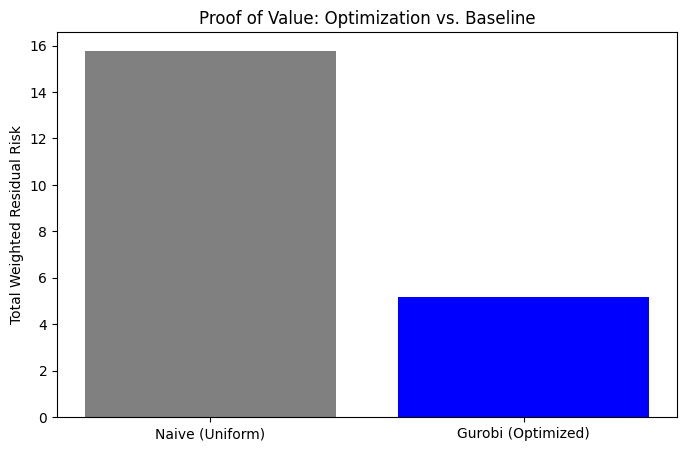

In [62]:
def run_baseline_comparison(input_df, target_date, budget):
    #Get efficiency model result
    gurobi_risk = run_comparison(input_df, target_date, budget, floor_value=0)
    
    #Calculate the naive risk with uniform distribution
    day_data = input_df[input_df['date'] == target_date].copy()
    num_precincts = day_data['ADDR_PCT_CD'].nunique()
    num_shifts = day_data['shift_window'].nunique()
    total_slots = num_precincts * num_shifts
    
    #Spread budget evenly across all slots
    avg_officers = budget / total_slots
    
    naive_risk = 0
    for _, row in day_data.iterrows():
        residual = max(0, row['predicted_incidents'] - (avg_officers * 0.05))
        weighted_residual = residual * (2.0 if row['high_risk'] == 1 else 1.0)
        naive_risk += weighted_residual
        
    return gurobi_risk, naive_risk

#Compare
B_VALIDATE = 300
demo_date = df['date'].max().strftime('%Y-%m-%d')

g_risk, n_risk = run_baseline_comparison(df, demo_date, B_VALIDATE)

if g_risk is not None:
    improvement = ((n_risk - g_risk) / n_risk) * 100
    
    print(f"--- VALIDATION RESULTS (Budget: {B_VALIDATE}) ---")
    print(f"Naive Baseline Risk: {n_risk:.4f}")
    print(f"Gurobi Optimized Risk: {g_risk:.4f}")
    print(f"Percent Improvement: {improvement:.2f}%")
    
    #Visualization Bar Chart
    plt.figure(figsize=(8, 5))
    plt.bar(['Naive (Uniform)', 'Gurobi (Optimized)'], [n_risk, g_risk], color=['gray', 'blue'])
    plt.ylabel('Total Weighted Residual Risk')
    plt.title('Proof of Value: Optimization vs. Baseline')
    plt.show()